In [1]:
import torch
import hydra
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import DictConfig, OmegaConf
from solo.args.pretrain import parse_cfg
from solo.methods.ta import BYOLWithTA
from hydra import compose, initialize
from solo.losses.byol import byol_loss_func

from pytorch_lightning import seed_everything

from solo.methods import METHODS

from solo.data.pretrain_dataloader import (
    FullTransformPipeline,
    NCropAugmentation,
    build_transform_pipeline,
    prepare_dataloader,
    prepare_datasets,
)

/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:35: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:93: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  contrast

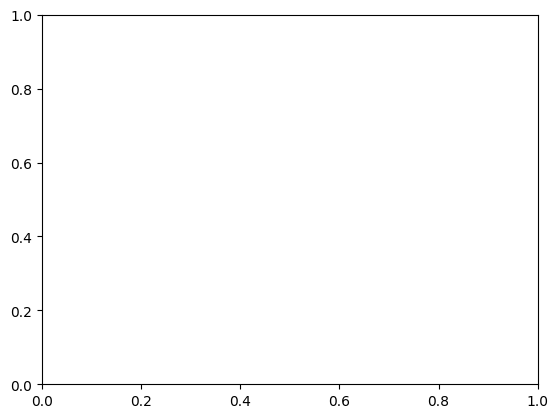

In [2]:
%matplotlib inline

fig, plots = plt.subplots()

In [3]:
with initialize(version_base=None, config_path="scripts/pretrain/cifar"):
    cfg = compose(config_name="byol-ta.yaml")

OmegaConf.set_struct(cfg, False)
cfg = parse_cfg(cfg)
seed_everything(cfg.seed)
model = METHODS[cfg.method](cfg)

# Load a pretrained model
weights = torch.load("trained_models/byol-ta/2j0mco0g/byol-ta-cifar10-2j0mco0g-ep=165.ckpt")
model.load_state_dict(weights['state_dict'])
model.eval()

Global seed set to 5


BYOLWithTA(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        

In [4]:
ax.imshow(model.value_matrix.weight.detach().cpu())
fig

NameError: name 'ax' is not defined

In [12]:
pipelines = []
for aug_cfg in cfg.augmentations:
    pipelines.append(
        NCropAugmentation(
            build_transform_pipeline(cfg.data.dataset, aug_cfg), aug_cfg.num_crops
        )
    )
transform = FullTransformPipeline(pipelines)

if cfg.debug_augmentations:
    print("Transforms:")
    print(transform)

train_dataset = prepare_datasets(
    cfg.data.dataset,
    transform,
    train_data_path=cfg.data.train_path,
    data_format=cfg.data.format,
    no_labels=cfg.data.no_labels,
    data_fraction=cfg.data.fraction,
)
train_loader = prepare_dataloader(
    train_dataset, batch_size=cfg.optimizer.batch_size, num_workers=cfg.data.num_workers
)

Files already downloaded and verified


In [13]:
train_loader_iterator = iter(train_loader)

In [14]:
# for (_, X, y) in train_loader:
#     break
img_batch = next(train_loader_iterator)
with torch.no_grad():
    model_inputs = img_batch[1][0]
output = model(model_inputs)

In [15]:
model.ax.imshow(output['feats'].detach().numpy())
model.fig

AttributeError: 'BYOLWithTA' object has no attribute 'ax'

In [120]:
def attention_weights(model, batch):
    out = super(type(model), model).training_step(batch, 0)
    student_z = []
    neg_cos_sim = 0
    student_weights_list = []
    teacher_weights_list = []
    for idx1 in range(model.num_large_crops):
            for idx2 in np.delete(range(model.num_crops), idx1):
                z = model.projector(out["feats"][idx1])
                student_z.append(out['feats'][idx1])
                with torch.no_grad():
                    momentum_z = model.momentum_projector(out["momentum_feats"][idx2])
                student_queries = model.query_matrix(z)
                student_keys = model.key_matrix(z)
                student_values = model.value_matrix(z)

                with torch.no_grad():
                    teacher_queries = model.momentum_query_matrix(momentum_z)
                    teacher_keys = model.momentum_key_matrix(momentum_z)
                    teacher_values = model.momentum_value_matrix(momentum_z)

                key_pool = (
                    torch.cat([student_keys, teacher_keys.detach()])
                    .transpose(0, 1)
                    .contiguous()
                )
                value_pool = torch.cat([student_values, teacher_values.detach()])

                d = student_queries.shape[-1]
                student_weights = torch.nn.functional.softmax(
                    torch.mm(student_queries, key_pool) / np.sqrt(d),
                    dim=-1,
                )

                student_y = torch.mm(student_weights, value_pool)
                p = model.predictor(student_y)

                with torch.no_grad():
                    teacher_weights = torch.nn.functional.softmax(
                        torch.mm(teacher_queries, key_pool) / np.sqrt(d),
                        dim=-1,
                    )
                    teacher_y = torch.mm(teacher_weights, value_pool)
                teacher_weights_list.append(teacher_weights)
                neg_cos_sim += byol_loss_func(p, teacher_y)
                
                student_weights_list.append(student_weights)
                teacher_weights_list.append(teacher_weights)

#         with torch.no_grad():
#             z_std = (
#                 torch.nn.functional.normalize(torch.stack(student_z[: model.num_large_crops]), dim=-1)
#                 .std(dim=1)
#                 .mean()
#             )
#     print(z_std)
    return student_weights_list, teacher_weights_list, neg_cos_sim 

In [121]:
with torch.no_grad():
    s_w, t_w, loss, s_o, t_o, s_z, t_z = attention_weights(model, img_batch)

In [123]:
queries = s_z[0]
keys = torch.cat([s_z[0], t_z[0]])
values = torch.cat([s_z[0], t_z[0]])

multihead_attn = torch.nn.MultiheadAttention(embed_dim=256, num_heads=1, batch_first=True)

In [138]:
def test_attention(model, queries, keys, values):
    student_queries = model.query_matrix(queries)
    student_keys = model.key_matrix(keys)
    student_values = model.value_matrix(values)
    d = student_queries.shape[-1]
    student_weights = torch.nn.functional.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)
    student_y = torch.mm(student_weights, student_values)
    return student_y

test_attention(model, queries, keys, values)

tensor([[ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781],
        [ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781],
        [ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781],
        ...,
        [ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781],
        [ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781],
        [ 179702.0000,  -33379.8594,   16211.7725,  ..., -109654.5625,
          -24555.2461,   66864.0781]], grad_fn=<MmBackward0>)

In [147]:
true_output, _ = torch.nn.functional.multi_head_attention_forward(
            queries,
            keys,
            values,
            embed_dim_to_check=256,
            num_heads=1,
            in_proj_weight=None,
            in_proj_bias=None,
            bias_k=None,
            bias_v=None,
            add_zero_attn=False,
            dropout_p=0.0,
            out_proj_bias=torch.zeros(256),
            out_proj_weight=torch.eye(256),
            training=False,
            key_padding_mask=None,
            need_weights=True,
            attn_mask=None,
            use_separate_proj_weight=True,
            q_proj_weight=model.query_matrix.weight,
            k_proj_weight=model.key_matrix.weight,
            v_proj_weight=model.value_matrix.weight,
            static_k=None,
            static_v=None,
        )

In [148]:
torch.allclose(true_output, s_o[0])

True

In [124]:
projection_layer = torch.nn.Linear(256, 256)
projection_layer.weight = torch.nn.Parameter(attn_params['out_proj.weight'])
# attn_params['out_proj.weight'].shape

In [125]:
attn_params = dict(multihead_attn.named_parameters())
with torch.no_grad():
    attn_params['in_proj_weight'][:256,:] = torch.nn.Parameter(model.query_matrix.weight)
    attn_params['in_proj_weight'][256:256*2,:] = torch.nn.Parameter(model.key_matrix.weight)
    attn_params['in_proj_weight'][256*2:256*3,:] = torch.nn.Parameter(model.value_matrix.weight)
attn_params['in_proj_weight']

Parameter containing:
tensor([[-0.1546,  0.1422,  0.0590,  ...,  0.1340, -0.0954, -0.0946],
        [ 0.1517, -0.0809, -0.0917,  ..., -0.0876,  0.0674,  0.0919],
        [-0.0619,  0.0934,  0.0680,  ...,  0.1073, -0.1225, -0.0920],
        ...,
        [-0.1090,  0.1540,  0.0658,  ...,  0.0820, -0.0661, -0.0916],
        [-0.0078,  0.0369, -0.0063,  ...,  0.0105, -0.0566,  0.0125],
        [ 0.1038, -0.0387, -0.0705,  ..., -0.0629,  0.1318,  0.1251]],
       requires_grad=True)

In [142]:
attn_params

{'in_proj_weight': Parameter containing:
 tensor([[-0.1546,  0.1422,  0.0590,  ...,  0.1340, -0.0954, -0.0946],
         [ 0.1517, -0.0809, -0.0917,  ..., -0.0876,  0.0674,  0.0919],
         [-0.0619,  0.0934,  0.0680,  ...,  0.1073, -0.1225, -0.0920],
         ...,
         [-0.1090,  0.1540,  0.0658,  ...,  0.0820, -0.0661, -0.0916],
         [-0.0078,  0.0369, -0.0063,  ...,  0.0105, -0.0566,  0.0125],
         [ 0.1038, -0.0387, -0.0705,  ..., -0.0629,  0.1318,  0.1251]],
        requires_grad=True),
 'in_proj_bias': Parameter containing:
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0

In [126]:
attn_output, attn_output_weights = multihead_attn(queries, keys, values)

In [127]:
attn_output

tensor([[-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062],
        [-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062],
        [-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062],
        ...,
        [-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062],
        [-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062],
        [-23710.3125,  25600.2773, -37170.5820,  ...,  43523.4023,
          13759.5762,  80416.4062]], grad_fn=<SqueezeBackward1>)

In [130]:
projection_layer(s_o[0])

tensor([[ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352],
        [ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352],
        [ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352],
        ...,
        [ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352],
        [ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352],
        [ 46098.3945, -20146.6074,  85161.6562,  ..., -19033.0156,
         -23077.0000, -43442.0352]], grad_fn=<AddmmBackward0>)

In [140]:
s_o[0].shape

torch.Size([256, 256])

In [131]:
torch.allclose(attn_output, projection_layer(s_o[0]))

False

In [149]:
s_w[0].argmax(dim=-1)

tensor([300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 3

In [150]:
t_w[0].argmax(dim=-1)

tensor([300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300,
        300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 300, 3

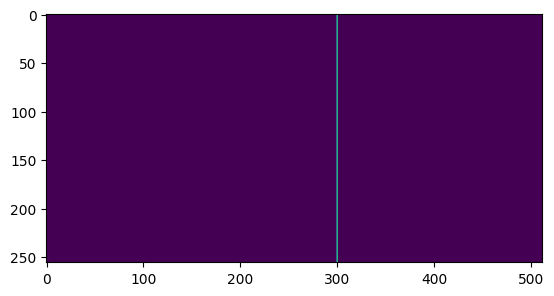

In [151]:
model.ax.imshow(s_w[0].detach().cpu())
model.fig

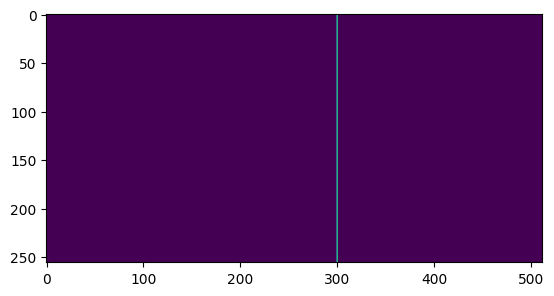

In [152]:
model.ax.imshow(t_w[0].detach().numpy())
model.fig

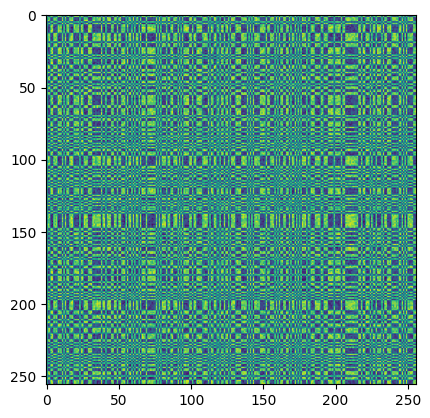

In [153]:
model.ax.imshow(model.query_matrix.weight.detach().numpy())
model.fig

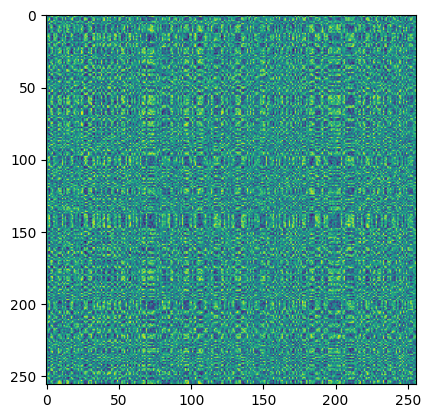

In [154]:
model.ax.imshow(model.key_matrix.weight.detach().numpy())
model.fig

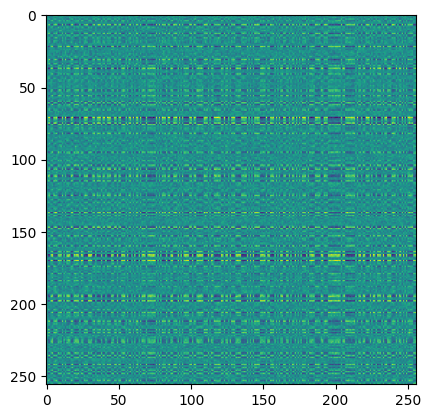

In [110]:
model.ax.imshow(model.value_matrix.weight.detach().numpy())
model.fig

In [131]:
torch.mm(s_w[0], s_w[0].t())

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])